In [17]:
#librerías necesarias
import numpy as np
import pandas as pd
from scipy.cluster.hierarchy import dendrogram
import matplotlib.pyplot as plt

punto 1.

In [31]:
def cluster_distance(C1, C2, linkage): #función distancia entre clusters
    pts1 = np.array(list(C1))
    pts2 = np.array(list(C2))
    if linkage == 'single':
        return np.min(np.linalg.norm(pts1[:, None] - pts2[None, :], axis=2))
    elif linkage == 'complete':
        return np.max(np.linalg.norm(pts1[:, None] - pts2[None, :], axis=2))
    elif linkage == 'average':
        return np.mean(np.linalg.norm(pts1[:, None] - pts2[None, :], axis=2))
    elif linkage == 'ward':
        mean1 = pts1.mean(axis=0)
        mean2 = pts2.mean(axis=0)
        n1 = pts1.shape[0]
        n2 = pts2.shape[0]
        return (n1 * n2) / (n1 + n2) * np.linalg.norm(mean1 - mean2)**2

    else:
        raise ValueError("Unknown linkage")


#matriz de distancias entre clusters
def compute_cluster_distances(clusters, linkage):
    D = {}
    for i in range(len(clusters)):
        for j in range(i+1, len(clusters)):
            D[(i, j)] = cluster_distance(clusters[i], clusters[j], linkage)
    return D


#agglomerative Clustering general
def AgglomerativeClustering(X, linkage='single'):
    n = len(X)

    # Cada punto es un cluster inicial con ID correcto
    clusters = {i: {i} for i in range(n)}

    # Para poder computar distancias, guardamos los vectores
    points = {i: X[i] for i in range(n)}

    Z = []
    next_id = n  # Primer ID disponible para clusters nuevos

    while len(clusters) > 1:
        min_dist = float("inf")
        best_pair = None

        # Buscar la pareja más cercana de clusters
        keys = list(clusters.keys())
        for i in range(len(keys)):
            for j in range(i+1, len(keys)):
                c1, c2 = keys[i], keys[j]

                pts1 = np.array([points[p] for p in clusters[c1]])
                pts2 = np.array([points[p] for p in clusters[c2]])

                dist = cluster_distance(pts1, pts2, linkage)

                if dist < min_dist:
                    min_dist = dist
                    best_pair = (c1, c2)

        c1, c2 = best_pair

        # Nuevo cluster
        new_cluster = clusters[c1] | clusters[c2]
        size = len(new_cluster)

        # Agregar entrada a la matriz Z
        Z.append([c1, c2, min_dist, size])

        # Actualizar diccionario de clusters
        del clusters[c1]
        del clusters[c2]
        clusters[next_id] = new_cluster

        next_id += 1

    return np.array(Z)

In [32]:
X= pd.read_csv("exercise1_data.csv", skiprows=1)
X

,2.0,10.0
0,2.0,5.0
1,8.0,4.0
2,5.0,8.0
3,1.0,2.0


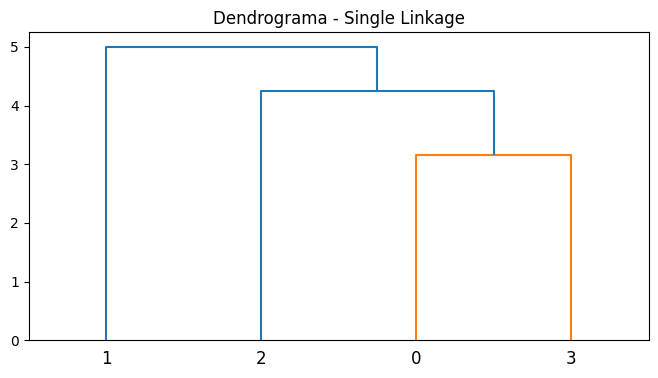

In [33]:
Z = AgglomerativeClustering(X.values, linkage='single')

plt.figure(figsize=(8,4))
dendrogram(Z)
plt.title("Dendrograma - Single Linkage")
plt.show()

punto 3.

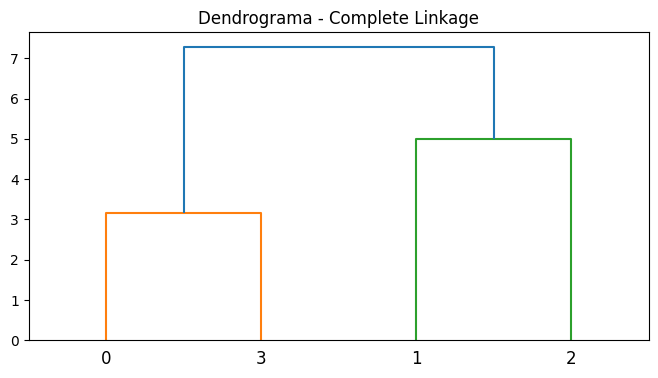

In [34]:
Z = AgglomerativeClustering(X.values, linkage='complete')

plt.figure(figsize=(8,4))
dendrogram(Z)
plt.title("Dendrograma - Complete Linkage")
plt.show()

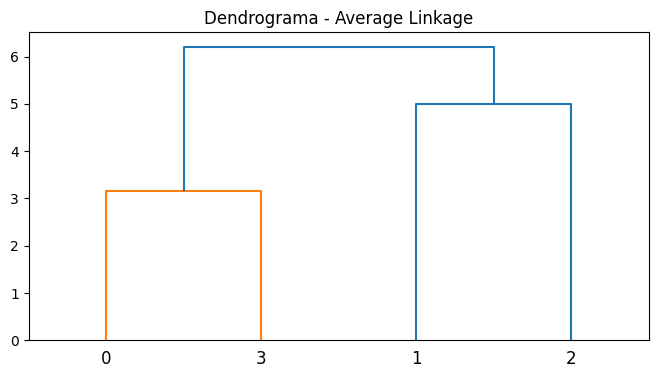

In [35]:
Z = AgglomerativeClustering(X.values, linkage='average')

plt.figure(figsize=(8,4))
dendrogram(Z)
plt.title("Dendrograma - Average Linkage")
plt.show()

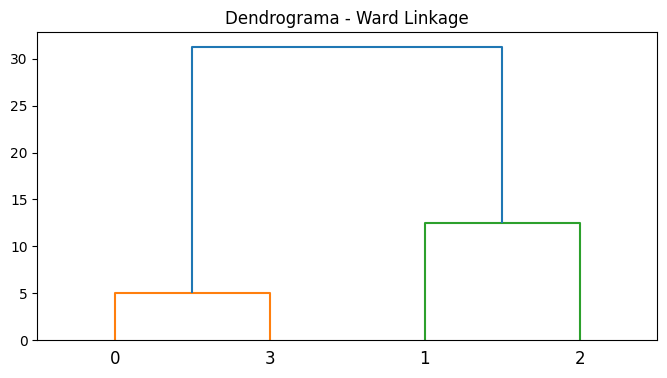

In [36]:
Z = AgglomerativeClustering(X.values, linkage='ward')

plt.figure(figsize=(8,4))
dendrogram(Z)
plt.title("Dendrograma - Ward Linkage")
plt.show()

In [ ]:
#de los dendrogramas generados podemos observar que cuando linkage es single los puntos se unen a una altura no tan diferente entre sí
#y no tienen una estructura como un árbol sino continua, además mediante el linkage ward los puntos se unen a una altura demasiado alta
#es decir que si fueran más puntos podría ser el que tiene un mayor tiempo de ejecución. De todas las variantes el mejor dendrograma es cuando linkage es average.